# How to Use Multi Hashing to Get Unique Vectors from an Array

## A. The Basics

In [1]:
from deduplicate_lib.plugins.duplicate_detection_algorithms.multi_hashing import MultiHashing
from deduplicate_lib.plugins.tolerance_calculators.natural_tolerance_plateau_probe import NaturalTolerancePlateauProbe
from deduplicate_lib.plugins.tolerance_calculators.perturbed_dataset_reclustering import PerturbedDatasetReclustering
import numpy as np
import matplotlib.pyplot as plt

### 1. Generating some realistic data

Many use cases for vector similarity checking involve inhomogenous distributions in vector space. These distributions often form identifiable clusters. The job of the algorithms is to determine at whether new entrants to this vector space are truly unique or something we have likely seen before. 

Lets start by creating data with a known number of clusters in vector space

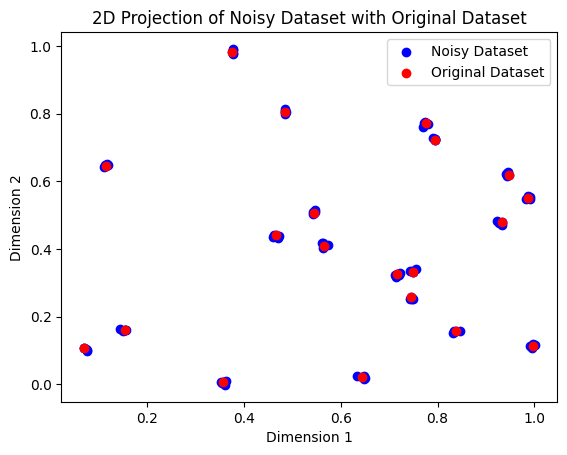

In [2]:
rng = np.random.default_rng(803) # for reproducibility

# Create a dataset of 20 vectors with 10 dimensions (any dimensionality would work, but 3 is nice for visualization)
dataset = rng.uniform(0, 1, size=(20, 10))

# about each vector we create similar vectors by adding small random noise, these represent vectors that we should consider duplicates
cluster_size=5
noisy_dataset = np.zeros((len(dataset) * cluster_size, dataset.shape[1])) # preallocate for original + 4 similar vectors
for i in range(len(dataset)):
    noisy_dataset[i*cluster_size] = dataset[i] # original vector
    for j in range(1, cluster_size):
        noise = rng.normal(0, 0.005, size=(dataset.shape[1])) # small noise
        noisy_dataset[i*cluster_size + j] = dataset[i % len(dataset)] + noise

plt.scatter(noisy_dataset[:, 0], noisy_dataset[:, 1], color='blue', label='Noisy Dataset')
plt.scatter(dataset[:, 0], dataset[:, 1], color='red', label='Original Dataset')
plt.legend()
plt.title('2D Projection of Noisy Dataset with Original Dataset')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.show()

We now have a dataset of 500 vectors in 100 seperate clusters

### 2. Creating the duplicate detection object

There are a variety to select from but lets go with Multi Hash as it is the name of the tutorial. Further on in this example we will look at exactly how it works but for now lets take at default.

Naively we could just run this with all default values. But no duplicate detection algorithm will perform particularly well without some tuning.

In [3]:

# Create a MultiHashing instance
dda = MultiHashing(dataset_array=noisy_dataset)
dda.pre_dda_processing() # this is optional, but will ensure that we reuse the same perturbation array for all vectors, which is important for testing and will save us some compute time
print(f"Unique structures found with default tolerance: {dda.get_dataset_unique_structures()}")

Unique structures found with default tolerance: 40


Observe that we get the wrong value here

### 3. Tuning the tolerance value with known distributions

We have multiple methods to tune the tolerance. The simplest of which is called *perturbed dataset reclustering* (PDR) which finds the optimal tolerance value for a dda object to return the desired number of clusters. This is helpful if we know how many clusters we should have prior to the prediction.

The tuning proces can take a while as the hash vector array must be reconstructed for all atoms every time the tolerance is changed, which happens alot throughout the optimisation process. 

In [4]:
# create a tolerance calculator instance with the same dataset and duplicate detection algorithm instancee
tc = PerturbedDatasetReclustering(duplicate_detection_algorithm_object=dda,
                                  tolerance_dataset_array=noisy_dataset,
                                  target_structures=len(dataset)) # we know there are 20 unique vectors in the original dataset, so we set this as our target for the tolerance calculator

tolerance=tc.calculate_tolerance()
print(f"Calculated tolerance: {tolerance}")

dda.tolerance = tolerance
print(f"Unique structures found with calculated tolerance: {dda.get_dataset_unique_structures()}")

Calculated tolerance: 1.7408245708150216
Unique structures found with calculated tolerance: 20


This is not particularly impressive as we know what the answer should be and provide the tolerance tuning the answer to optimise to. However, it can be userful if you are expecting to add more data and anticipate a similar distribution moving forward

###  4. Tuning the tolerance without known distributions

This is a significantly more difficult task. We use the natural tolerance plateau probe method instead. This method works by checking the number of reported structures for a range of tolerances, if there is not significant change in the number of structures with increasing tolerance this indicates a natural point where clusters, defined by this window of tolerance values are reasonably well seperated.

> **Note**
> This technique is a bit more expensive than the PDR, default settings for 500 structures takes approximately two minutes. You can reduce the fidelity of the probe by setting `tc.probe_steps` to a lower number (default is 100) or take a sub sample of the dataset to speed things up

In [5]:
tc = NaturalTolerancePlateauProbe(duplicate_detection_algorithm_object=dda,
                                  tolerance_dataset_array=noisy_dataset,
                                  )

tolerance = tc.calculate_tolerance()
print(f"Calculated tolerance with NaturalTolerancePlateauProbe: {tolerance}")
dda.tolerance = tolerance
print(f"Unique structures found with calculated tolerance from NaturalTolerancePlateauProbe: {dda.get_dataset_unique_structures()}")

Calculated tolerance with NaturalTolerancePlateauProbe: 0.8646666951008833
Unique structures found with calculated tolerance from NaturalTolerancePlateauProbe: 24


We get much closer than default values using this strategy

### 5. Adding to the dataset

Often it is the case in workflows that use similarity checking to ensure that what we add is significantly unique. Using the same tolerance we generated with NTPP lets check some data and add unique ones using `duplicate_check()`

In [6]:

exact_copy_input_vector = dataset[0]
rng = np.random.default_rng(805) # different seed to ensure different perturbations than those used in the dataset creation
perturbed_within_tolerance_vector = dataset[0] + rng.normal(0, 0.001, size=(dataset.shape[1]))
perturbed_outside_tolerance_vector = dataset[0] + rng.normal(0, 0.5, size=(dataset.shape[1]))


for test_vector in [exact_copy_input_vector, perturbed_within_tolerance_vector, perturbed_outside_tolerance_vector]:
    dda.input_vector = test_vector
    print(f'Input vector is duplicate of vector in dataset: {dda.duplicate_check()}')


Input vector is duplicate of vector in dataset: True
Input vector is duplicate of vector in dataset: True
Input vector is duplicate of vector in dataset: False


We can see that both an exact copy and a slight perturbation of results return duplicates, where as a significantly perturbed vector is considered unique. Lets add the unique vector to the dataset.

In [7]:
dda.input_vector = perturbed_outside_tolerance_vector
dda.add_input_vector_to_dda()

print(f"Unique structures found after adding input vector: {dda.get_dataset_unique_structures()}")

Unique structures found after adding input vector: 25


We now have one more unique structure found

### 6. Returning a unique array

Finally, we will retrieve the unique structures from the array using the primary `deduplicate` function

In [8]:
unique_array=dda.deduplicate()
print(f"Unique array shape: {unique_array.shape}")

Unique array shape: (25, 10)


For clarity we will repeat all the necessary steps on how to get a unique dataset from your data below

In [ ]:
dda = MultiHashing(dataset_array=noisy_dataset, perturbations=10)
dda.pre_dda_processing()

tc = NaturalTolerancePlateauProbe(duplicate_detection_algorithm_object=dda,
                                  tolerance_dataset_array=noisy_dataset,)

# Or use PDR for tolerance calculation by uncommenting the following lines and commenting out the NaturalTolerancePlateauProbe lines above

# tc = PerturbedDatasetReclustering(duplicate_detection_algorithm_object=dda,
#                                   tolerance_dataset_array=noisy_dataset,
#                                   target_structures=len(dataset))

tolerance = tc.calculate_tolerance()

print(f"Calculated tolerance: {tolerance}")

dda.tolerance = tolerance
dda.get_dataset_unique_structures()
unique_array = dda.deduplicate()
print(f"Unique array shape: {unique_array.shape}\n")

unique_indices = dda.get_unique_vector_indices()
for i in range(len(dataset)):
    valid_indices = unique_indices[unique_indices // cluster_size == i]
    print(f'unique vector indices for cluster {i}: {valid_indices}')
    if len(valid_indices) == 0:
        print('no unique vectors found for this cluster')


Calculated tolerance: 0.8646666951008833
Unique array shape: (24, 10)

unique vector indices for cluster 0: [0]
unique vector indices for cluster 1: [5]
unique vector indices for cluster 2: [10]
unique vector indices for cluster 3: [15]
unique vector indices for cluster 4: [20]
unique vector indices for cluster 5: [25 26]
unique vector indices for cluster 6: [30]
unique vector indices for cluster 7: [35 36]
unique vector indices for cluster 8: [40]
unique vector indices for cluster 9: [45]
unique vector indices for cluster 10: [50]
unique vector indices for cluster 11: [55]
unique vector indices for cluster 12: [60 64]
unique vector indices for cluster 13: [65]
unique vector indices for cluster 14: [70]
unique vector indices for cluster 15: [75 76]
unique vector indices for cluster 16: [80]
unique vector indices for cluster 17: [85]
unique vector indices for cluster 18: [90]
unique vector indices for cluster 19: [95]


Here is the indices of the vectors the DDA considers suffciently unique. We observe that all original vectors are found are found for each cluster (every multiple of 5) and only a few have duplicate vectors.

## In Summary
1. We created data that has different orders of randomness where smaller perturbations should be considered similar to the larger random points
2. We created duplicate detection object and assigned the dataset
3. we created a tolerance calculator object and assigned the dataset and the duplicate detection object
4. We used the tolerance calculator object to find a suitable tolerance
5. We assigned this tolerance to the duplicate detection object
6. We found the unique vectors in the dataset using the duplicate detection object

the duplicate detection object and tolerance calculator are intertchangable,

You can replace all instances of `MultiHashing` with `DistanceMatrix` and see how they differ. 